In [7]:
!pip install -U transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 103.7 MB/s eta 0:00:00


In [6]:
from transformers import pipeline

pipe = pipeline("text-classification", model="SamLowe/roberta-base-go_emotions", top_k=None)
result = pipe("Thanks for using it.")
print(result)

config.json:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

[[{'label': 'gratitude', 'score': 0.990486204624176}, {'label': 'approval', 'score': 0.01174356509000063}, {'label': 'neutral', 'score': 0.007546530105173588}, {'label': 'admiration', 'score': 0.006425146479159594}, {'label': 'realization', 'score': 0.005557856988161802}, {'label': 'optimism', 'score': 0.005347386002540588}, {'label': 'annoyance', 'score': 0.004940389655530453}, {'label': 'joy', 'score': 0.0032554762437939644}, {'label': 'disapproval', 'score': 0.002784064505249262}, {'label': 'amusement', 'score': 0.00259085139259696}, {'label': 'confusion', 'score': 0.00254080630838871}, {'label': 'excitement', 'score': 0.0021751760505139828}, {'label': 'sadness', 'score': 0.002045692875981331}, {'label': 'relief', 'score': 0.0018557028379291296}, {'label': 'caring', 'score': 0.0018422577995806932}, {'label': 'disappointment', 'score': 0.0016654846258461475}, {'label': 'curiosity', 'score': 0.001617024070583284}, {'label': 'love', 'score': 0.0015522127505391836}, {'label': 'surprise'

In [15]:
emotion_labels=emotion("I'm very happy with this")

In [16]:
emotion_labels

[{'label': 'joy', 'score': 0.9028748273849487}]

In [17]:
emotion_labels[0]['label']

'joy'

In [19]:
import pandas as pd

df = pd.read_parquet("hf://datasets/google-research-datasets/go_emotions/raw/train-00000-of-00001.parquet")

In [21]:
df=df[:100]

In [26]:
df.head()

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1.548381e+09,1,False,0,...,0,0,0,0,0,0,0,1,0,0
1,>sexuality shouldn’t be a grouping category I...,eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1.548084e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,0
2,"You do right, if you don't care then fuck 'em!",ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1.546428e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,1
3,Man I love reddit.,eeibobj,MrsRobertshaw,facepalm,t3_ahulml,t3_ahulml,1.547965e+09,18,False,0,...,1,0,0,0,0,0,0,0,0,0
4,"[NAME] was nowhere near them, he was by the Fa...",eda6yn6,American_Fascist713,starwarsspeculation,t3_ackt2f,t1_eda65q2,1.546669e+09,2,False,0,...,0,0,0,0,0,0,0,0,0,1


In [20]:
df.shape

(211225, 37)

In [22]:
df.shape

(100, 37)

In [30]:
df['text'][1:10].apply(emotion)

,text
1,"[{'label': 'neutral', 'score': 0.8013329505920..."
2,"[{'label': 'anger', 'score': 0.5940459370613098}]"
3,"[{'label': 'love', 'score': 0.9495323300361633}]"
4,"[{'label': 'neutral', 'score': 0.9643282890319..."
5,"[{'label': 'gratitude', 'score': 0.92007511854..."
6,"[{'label': 'admiration', 'score': 0.7483757138..."
7,"[{'label': 'excitement', 'score': 0.4945226311..."
8,"[{'label': 'admiration', 'score': 0.9445617794..."
9,"[{'label': 'amusement', 'score': 0.86800706386..."


In [33]:
def get_emotion_label(text):
  return(emotion(text)[0]['label'])

In [35]:
get_emotion_label("How terrible D3.js is")

'fear'

In [34]:
df['text'][1:10].apply(get_emotion_label)

,text
1,neutral
2,anger
3,love
4,neutral
5,gratitude
6,admiration
7,excitement
8,admiration
9,amusement


In [36]:
df['emotion']=df['text'].apply(get_emotion_label)

/tmp/ipykernel_475/876447806.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['emotion']=df['text'].apply(get_emotion_label)


In [37]:
df

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral,emotion
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1.548381e+09,1,False,0,...,0,0,0,0,0,0,1,0,0,sadness
1,>sexuality shouldn’t be a grouping category I...,eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1.548084e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,neutral
2,"You do right, if you don't care then fuck 'em!",ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1.546428e+09,37,False,0,...,0,0,0,0,0,0,0,0,1,anger
3,Man I love reddit.,eeibobj,MrsRobertshaw,facepalm,t3_ahulml,t3_ahulml,1.547965e+09,18,False,0,...,0,0,0,0,0,0,0,0,0,love
4,"[NAME] was nowhere near them, he was by the Fa...",eda6yn6,American_Fascist713,starwarsspeculation,t3_ackt2f,t1_eda65q2,1.546669e+09,2,False,0,...,0,0,0,0,0,0,0,0,1,neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,What? The claim is 2018 best shooters. Not ove...,edo5n5f,What_A_Smurf,Blackops4,t3_aebbiv,t1_edo4j6s,1.547075e+09,61,False,0,...,0,0,0,0,0,0,0,0,0,curiosity
96,"That's professor [NAME] to you, savage!",eejfjoa,DrelltheUnclean,TIHI,t3_ahuxe8,t1_eejfhn0,1.547999e+09,41,False,0,...,0,0,0,0,0,0,0,0,0,neutral
97,Let go or you will be dragged,eeqi8r7,scotty61990,dating_advice,t3_aiu6i3,t3_aiu6i3,1.548207e+09,36,False,0,...,0,0,0,0,0,0,0,0,0,neutral
98,No we're getting Kinsler and be happy with it,eczowjx,dualme,Padres,t3_abehvh,t1_eczoc0l,1.546314e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,joy


In [38]:
import seaborn as sns

Text(0.5, 1.0, 'Emotional Distribution')

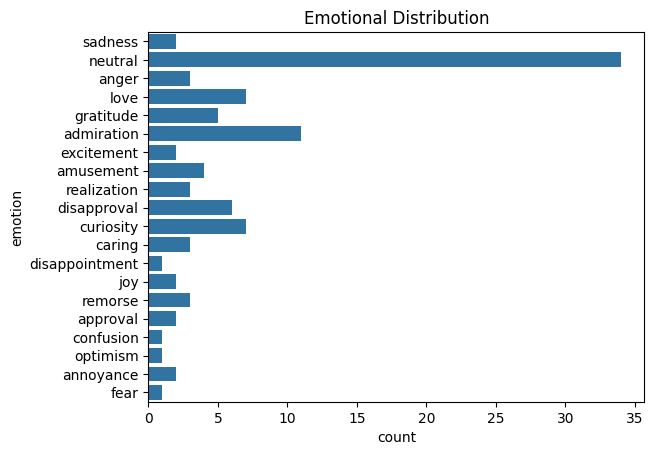

In [39]:
sns.countplot(data=df,y='emotion').set_title("Emotional Distribution")